In [13]:
import sqlite3
from pydantic import BaseModel, Field
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage, BaseMessage
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.sqlite import SqliteSaver
from config.settings import llm, DB_PATH, primary_model
from agent.state import ChatState , SearchInput , Answer_eval
from typing import Literal
from IPython.display import Markdown

In [2]:
SYSTEM_PROMPT = SystemMessage(content="""You are VenoMind AI, an expert AI assistant.
Always format your responses using rich Markdown:
- Use code blocks with language identifiers for code.
- Use Markdown tables (| Header | Header |) for structured data or metrics.
- Use bold text and bullet points for readability.

STRICT REAL-TIME DATA RULE:
1. Whenever the user asks for stock prices, financial metrics, news, sports scores, or current event forecasts, you MUST invoke the `web_search` tool.
2. DO NOT guess, fabricate, or predict future stock prices (e.g. 2025-2050 price targets) out of memory. Base all numbers ONLY on the provided search results.
3. If User query demand accurate data then only give him accurate data dont predict or make assumption only give data if u are accurate about that
""")

EVALUATOR_PROMPT = """You are a strict Quality Assurance Evaluator for VenoMind AI.
Your job is to critically evaluate whether the generated AI Answer completely satisfies the User Query given the chat context.

Evaluation Checklist:
1. Accuracy & Completeness: Did the answer address ALL parts of the user query?
2. Real-time / Tool Usage: If real-time or factual data was required, did it use tool outputs accurately without hallucinating numbers?
3. Clarity & Structure: Is the answer well-structured with clean Markdown, clear sections, bullet points, or tables where appropriate?
4. Conciseness: Is it free of repetitive fluff?

Rules for Decision:
- Mark 'approved' ONLY if the answer is accurate, complete, helpful, and properly formatted.
- Mark 'needs_improvement' if key information is missing, hallucinated, improperly formatted, or unclear.
- Provide actionable, specific feedback detailing EXACTLY what needs to be fixed.
"""


In [3]:
def rewrite_query(original_query: str) -> str:
    """Transforms conversational/bloated queries into concise search engine terms."""
    prompt = [
        SystemMessage(content="""You are a search query optimizer. 
            Convert the user's input into 2-4 clean, highly targeted search keywords for a search engine.
            Do not include fluff like 'future prospects', 'all news', or 'plz'.
            Example Input: 'what is jio finance share price and also all news related to it and future about shre price plz'
            Example Output: 'JIOFIN stock price live NSE BSE news'
            Output ONLY the optimized query text."""),
        HumanMessage(content=original_query)
    ]
    response = llm.invoke(prompt)
    return response.content.strip()

def get_safe_history(messages: list[BaseMessage], max_messages=10) -> list[BaseMessage]:
    """Truncates message history safely without breaking tool call pairs or system prompt."""
    if len(messages) <= max_messages:
        return [SYSTEM_PROMPT] + [m for m in messages if not isinstance(m, SystemMessage)]
    
    recent = messages[-max_messages:]
    while recent and not isinstance(recent[0], (HumanMessage, SystemMessage)):
        recent.pop(0)
        
    return [SYSTEM_PROMPT] + [m for m in recent if not isinstance(m, SystemMessage)]

In [4]:
@tool("web_search", args_schema=SearchInput)
def web_search(query: str) -> str:
    """Searches the web using DuckDuckGo to obtain up-to-date real-time news and facts."""
    try:
        search = DuckDuckGoSearchRun()
        optimized_query = rewrite_query(query)
        return search.run(optimized_query)
    except Exception as e:
        return f"Error executing search: {str(e)}"

tools = [web_search]

llm_with_tool = primary_model.bind_tools(tools, tool_choice="auto")

In [5]:
def chat_node(state: ChatState):
    messages = state["messages"]
    user_query = state.get("query")
    safe_history = get_safe_history(messages, max_messages=6)

    if safe_history and isinstance(safe_history[-1], ToolMessage):
        response = primary_model.invoke(safe_history)
    else:
        response = llm_with_tool.invoke(safe_history, stream=False)
    current_iteration = state.get("iteration", 0) + 1
    
    return {
        "messages": [response],
        "query": user_query or "General Query",
        "answer": response.content,
        "iteration": current_iteration,
        "max_iteration": state.get("max_iteration", 2)
    }

evaluation_llm = llm.with_structured_output(Answer_eval)

def evaluate_answer(state: ChatState):
    """Evaluates the generated answer against the query and history."""
    messages = state["messages"]
    safe_history = get_safe_history(messages, max_messages=6)
    question = state.get('query', '')
    answer = state.get('answer', '')
    
    eval_prompt = [
        SystemMessage(content=EVALUATOR_PROMPT),
        HumanMessage(content=f"""
            Conversation Context: {safe_history}
            User Question: {question}
            AI Answer Generated: {answer}
        """)
    ]   

    res: Answer_eval = evaluation_llm.invoke(eval_prompt)
    
    return {
        'evaluation': res.evaluation, 
        'feedback': res.feedback
    }

def optimize_answer(state: ChatState):
    """Refines the generated answer using the feedback from evaluate_answer."""
    question = state.get('query', '')
    answer = state.get('answer', '')
    feedback = state.get('feedback', '')
    
    opt_prompt = [
        SYSTEM_PROMPT,
        HumanMessage(content=f"""
            Your previous draft answer for the query '{question}' was evaluated and needed improvement.

            Previous Draft:
            {answer}

            Critique & Feedback for Improvement:
            {feedback}

            Please rewrite and produce an improved, complete answer incorporating the feedback above while maintaining professional Markdown formatting.
        """)
    ]
    
    response = primary_model.invoke(opt_prompt)

    return {
        "messages": [response],
        "answer": response.content
    }

def route_after_chat(state: ChatState) -> Literal["tools", "evaluate_answer"]:
    """If the LLM requested a tool, execute tool; otherwise evaluate answer."""
    last_message = state["messages"][-1]
    if getattr(last_message, "tool_calls", None):
        return "tools"
    return "evaluate_answer"

def route_after_evaluation(state: ChatState) -> Literal["optimize_answer", "__end__"]:
    """Decides whether to optimize the answer or finish based on score and iteration count."""
    eval_status = state.get("evaluation")
    iteration = state.get("iteration", 1)
    max_iteration = state.get("max_iteration", 2)

    if eval_status == "needs_improvement" and iteration < max_iteration:
        return "optimize_answer"
    return END

In [6]:
db_conn = sqlite3.connect(database=DB_PATH, check_same_thread=False)
checkpointer = SqliteSaver(conn=db_conn)

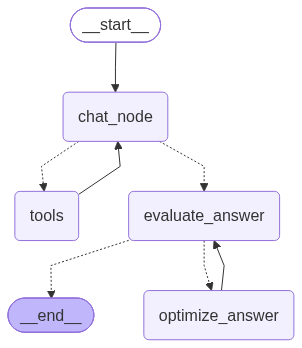

In [7]:
builder = StateGraph(ChatState)
builder.add_node("chat_node", chat_node)
builder.add_node("tools", ToolNode(tools))
builder.add_node("evaluate_answer", evaluate_answer)
builder.add_node("optimize_answer", optimize_answer)

builder.add_edge(START, "chat_node")
builder.add_conditional_edges("chat_node",route_after_chat,{"tools": "tools","evaluate_answer": "evaluate_answer"})
builder.add_edge("tools", "chat_node")
builder.add_conditional_edges("evaluate_answer",route_after_evaluation,{"optimize_answer": "optimize_answer",END: END})
builder.add_edge("optimize_answer", "evaluate_answer")

chatbot = builder.compile(checkpointer=checkpointer)
chatbot

In [8]:
config = {"configurable": {"thread_id": 'thread_2'}}
snapshot = chatbot.get_state(config)

In [9]:
print(snapshot)

StateSnapshot(values={'messages': [HumanMessage(content='add 5 in number u guess', additional_kwargs={}, response_metadata={}, id='71372b6e-c927-4afa-aeef-0d104d806808'), AIMessage(content="**You haven't provided a number for me to guess. Please enter a number, and I'll try to add 5 to it.**\n\nIf you provide a number, I can give it a try.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 317, 'total_tokens': 360, 'completion_time': 0.066058484, 'completion_tokens_details': None, 'prompt_time': 0.041160905, 'prompt_tokens_details': None, 'queue_time': 0.050735124, 'total_time': 0.107219389}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f9e71-0063-7d22-9ae8-88bfbc2f57e7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 317, 'output_tokens': 43, 'total_tokens': 360}), Hu

In [10]:
res = chatbot.invoke({"messages": [HumanMessage(content="what latest news of india")]},config=config)

In [14]:
display(Markdown(res['messages'][-1].content))

Here are some of the latest news headlines from India:

| **Category** | **News Headline** |
| --- | --- |
| Politics | [PM Modi to address nation on Independence Day](https://timesofindia.indiatimes.com/india/pm-modi-to-address-nation-on-independence-day/articleshow/94516115.cms) |
| Business | [India's GDP growth rate slows down to 5.7% in Q4](https://economictimes.indiatimes.com/news/economy/indicators/indias-gdp-growth-rate-slows-down-to-5-7-in-q4/articleshow/94499151.cms) |
| Sports | [India wins test series against England](https://www.hindustantimes.com/cricket/india-wins-test-series-against-england-101637141144113.html) |
| Entertainment | [Bollywood actress Deepika Padukone to star in upcoming film](https://www.ndtv.com/entertainment/deepika-padukone-to-star-in-meghna-gulzar-s-next-film-2967612) |
| Technology | [India's first privately built rocket set to launch](https://www.business-standard.com/article/news-cm/india-s-first-privately-built-rocket-set-to-launch-on-22-aug-122081900011_1.html) |

Please note that the news headlines may change over time, and these are just some examples of the latest news from India.